## Figure 1

The input files are available at [our repository on Zenodo](https://doi.org/10.5281/zenodo.19499423).

In [1]:
import numpy as np
import pandas as pd

import scanpy as sc

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

### Read the data

In [2]:
adata_S1 = sc.read_h5ad('stereoseq_data_analysis/Sample1_cellbin_adjusted.h5ad')
adata_S2 = sc.read_h5ad('stereoseq_data_analysis/Sample2_cellbin_adjusted.h5ad')

### Figure 1b - color the subregions

In [3]:
## Define color maps
base_colors = sns.color_palette('colorblind')

region_color_map = {
    'Cortex': base_colors[0],     # e.g., blue
    'WM': base_colors[1],         # e.g., orange
    'HPC': base_colors[2],        # e.g., green
    'Thalamus': base_colors[3],   # e.g., red
    'Midbrain': base_colors[4],   # e.g., purple
}

def adjust_lightness(color, factor=1.0):
    r, g, b = to_rgb(color)
    return tuple(min(1, max(0, c * factor)) for c in (r, g, b))

subregion_color_map = {
    # Cortex and its layers (shades of blue)
    'Cortex': adjust_lightness(region_color_map['Cortex'], 1.4),
    'L23': adjust_lightness(region_color_map['Cortex'], 1.1),
    'L4': adjust_lightness(region_color_map['Cortex'], 0.8),
    'L5': adjust_lightness(region_color_map['Cortex'], 0.5),
    'L6': adjust_lightness(region_color_map['Cortex'], 0.2),

    'WM': region_color_map['WM'],

    # HPC subregions (shades of green)
    'Subiculum': adjust_lightness(region_color_map['HPC'], 1.2),
    'CA1_ML': adjust_lightness(region_color_map['HPC'], 1),
    'CA2': adjust_lightness(region_color_map['HPC'], 0.8),
    'CA3_ML': adjust_lightness(region_color_map['HPC'], 0.6),
    'DG_ML': adjust_lightness(region_color_map['HPC'], 0.4),

    'Thalamus': region_color_map['Thalamus'],
    'Midbrain': region_color_map['Midbrain'],
}


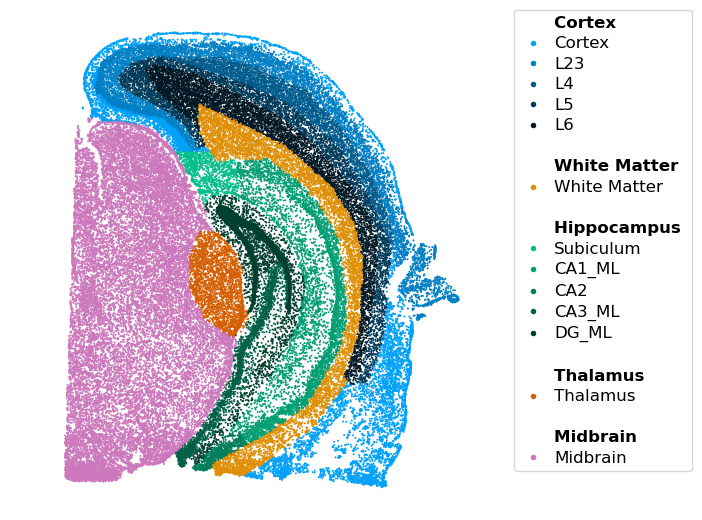

In [4]:
fig, ax = plt.subplots(figsize=(6.5,6.5))

scatter = sns.scatterplot(data=adata_S1.obs, x='x', y='y',
                          hue='subregion', s=2,
                          edgecolor='none', ax=ax,
                         hue_order=['Cortex', 'L23', 'L4', 'L5', 'L6', 'WM', 
                                    'Subiculum', 'CA1_ML', 'CA2', 'CA3_ML', 
                                    'DG_ML', 'Thalamus', 'Midbrain'],
                         palette=subregion_color_map,
                         rasterized=True)

# Remove ticks, labels, and axes spines
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='datalim')

# Helper to make subtitles
def subtitle(text):
    return Line2D([0], [0], color='none', label=text)

# Helper to make a spacer (blank line)
def spacer():
    return Line2D([0], [0], color='none', label=' ')

# Build legend entries
legend_elements = []

# Cortex group
legend_elements.append(subtitle('Cortex '))
legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', label='Cortex', markerfacecolor=subregion_color_map['Cortex'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='L23', markerfacecolor=subregion_color_map['L23'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='L4', markerfacecolor=subregion_color_map['L4'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='L5', markerfacecolor=subregion_color_map['L5'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='L6', markerfacecolor=subregion_color_map['L6'], markersize=5),
    spacer()
])

# WM
legend_elements.append(subtitle('White Matter '))
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='White Matter', markerfacecolor=subregion_color_map['WM'], markersize=5))
legend_elements.append(spacer())

# HPC
legend_elements.append(subtitle('Hippocampus '))
legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', label='Subiculum', markerfacecolor=subregion_color_map['Subiculum'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='CA1_ML', markerfacecolor=subregion_color_map['CA1_ML'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='CA2', markerfacecolor=subregion_color_map['CA2'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='CA3_ML', markerfacecolor=subregion_color_map['CA3_ML'], markersize=5),
    Line2D([0], [0], marker='o', color='w', label='DG_ML', markerfacecolor=subregion_color_map['DG_ML'], markersize=5),
    spacer()
])

# Thalamus
legend_elements.append(subtitle('Thalamus '))
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Thalamus', markerfacecolor=subregion_color_map['Thalamus'], markersize=5))
legend_elements.append(spacer())

# Midbrain
legend_elements.append(subtitle('Midbrain '))
legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Midbrain', markerfacecolor=subregion_color_map['Midbrain'], markersize=5))

# Add legend
legend = ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    title='',
    handletextpad=0.5,
    borderaxespad=0.,
    labelspacing=0.4  # normal spacing
)

# Make subtitles bold/larger
for text in legend.get_texts():
    text.set_fontsize(12)
    if text.get_text() in ['Cortex ', 'White Matter ', 'Hippocampus ', 'Thalamus ', 'Midbrain ']:
        text.set_fontsize(12)
        text.set_fontweight('bold')

plt.show()


### Figure 1c - Cell-type annotations 

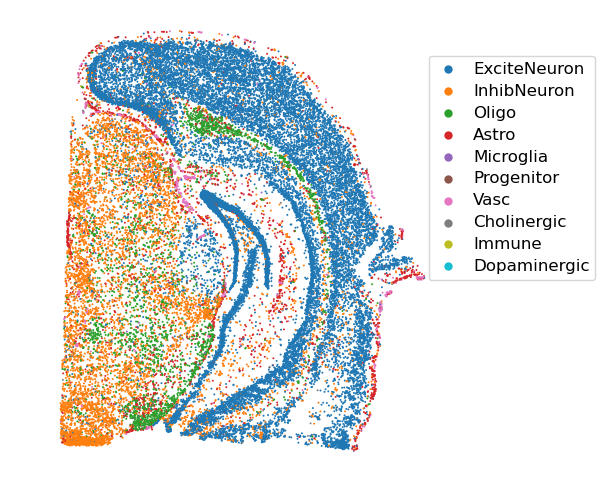

In [5]:
fig, ax = plt.subplots(figsize=(6,6))

scatter = sns.scatterplot(data=adata_S1.obs[adata_S1.obs['spot_class'] == 'singlet'], 
                          x='x', y='y',
                          hue='first_type', s=2, 
                          edgecolor='none', ax=ax,
                          hue_order=['ExciteNeuron', 'InhibNeuron', 
                                     'Oligo', 'Astro', 'Microglia',
                                     'Progenitor','Vasc', 'Cholinergic',
                                     'Immune', 'Dopaminergic'], 
                          rasterized=True)

# Remove ticks, labels, and axes spines
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='datalim')

# Customize legend
legend = ax.legend(
    title='',
    bbox_to_anchor=(0.9, 0.9),   # Move it outside the right
    loc='upper left',           # Align top-left of legend box to that point
    borderaxespad=0.
)
for text in legend.get_texts():
    text.set_fontsize(12)

# Increase legend marker size
for handle in legend.legend_handles:
    handle.set_markersize(6)  # Adjust size; default is ~4–5

plt.show()


### Figure 1d - Alignment

In [6]:
adata = sc.concat((adata_S1, adata_S2))

/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/anndata/_core/anndata.py:1759: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/anndata/_core/anndata.py:1759: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


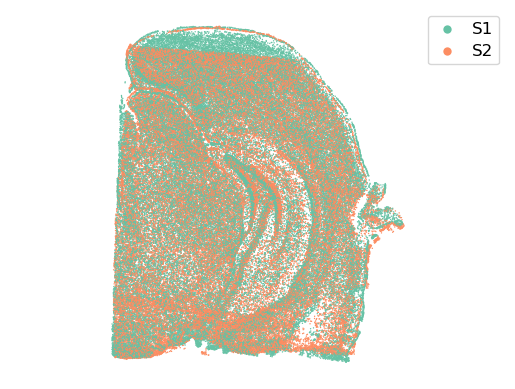

In [7]:
fig, ax = plt.subplots()

# .sample(frac=1) to ensure the points are mixed instead of Sample 2 on top
scatter = sns.scatterplot(data=adata.obs.sample(frac=1), 
                          x='x_aligned', y='y_aligned',
                          hue='sample', s=1, palette='Set2',
                          edgecolor='none', ax=ax,
                          hue_order=['S1','S2'], rasterized=True)

# Remove ticks, labels, and axes spines
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='datalim')

# Customize legend
legend = ax.get_legend()
legend.set_title('')

for text in legend.get_texts():
    text.set_fontsize(12)

# Increase legend marker size
for handle in legend.legend_handles:
    handle.set_markersize(6)  # Adjust size; default is ~4–5

plt.show()


### Figure 1e - UMI density

In [8]:
adata_S1_bin = sc.read_h5ad('stereoseq_data_analysis/sample1_bin50.h5ad')

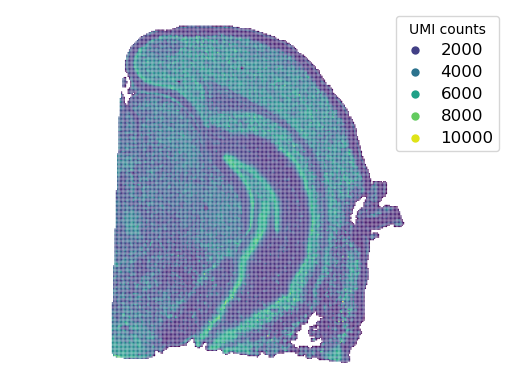

In [9]:
fig, ax = plt.subplots()

scatter = sns.scatterplot(data=adata_S1_bin.obs, x='x', y='y',
                          hue='total_counts', s=1, palette='viridis',
                          edgecolor='none', ax=ax, rasterized=True)

# Remove ticks, labels, and axes spines
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='datalim')

# Customize legend
legend = ax.get_legend()
legend.set_title('UMI counts')

for text in legend.get_texts():
    text.set_fontsize(12)

for handle in legend.legend_handles:
    handle.set_markersize(6)  # Adjust size; default is ~4–5

plt.show()
